# RetailPulse: AI-Powered Sales & Retail Analytics Platform
## Day 1 — Data Generation & Exploratory Data Analysis (v2)

**Module:** Data Layer (Phase 1)

**v2 revision:** the first version of this generator assigned customers to transactions uniformly at random across the whole date range, which produced almost no genuine churn (nearly every customer had *some* purchase in any 90-day window by chance). This version gives each customer an explicit **lifecycle** — a signup date, an individual purchase rate, and either sustained activity through the end of the dataset ("loyal") or a genuine dropout point partway through ("churned") — so Day 9's churn model has real signal to learn.

In [1]:
import os
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

RAW_DIR = "../data/raw"
PROCESSED_DIR = "../data/processed"
REPORTS_DIR = "../reports"
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)

RNG = np.random.default_rng(seed=7)

## 1. Configuration

In [2]:
N_PRODUCTS   = 120
N_CUSTOMERS  = 5000
START_DATE   = datetime(2023, 1, 1)
END_DATE     = datetime(2024, 12, 31)
TOTAL_DAYS   = (END_DATE - START_DATE).days
COUNTRIES    = ["United Kingdom", "Germany", "France", "Spain", "Netherlands",
                "Ireland", "Australia", "Sweden", "Switzerland", "Portugal"]
COUNTRY_WEIGHTS = [0.55, 0.09, 0.08, 0.06, 0.06, 0.05, 0.04, 0.03, 0.02, 0.02]
CATEGORIES = ["Home Decor", "Kitchenware", "Stationery", "Toys",
              "Seasonal", "Gifts", "Bags", "Lighting"]

CHURN_SHARE = 0.45   # fraction of customers who genuinely drop off before the dataset ends

## 2. Products Master

In [3]:
def build_products(n=N_PRODUCTS):
    stock_codes = [f"{10000+i}" for i in range(n)]
    categories = RNG.choice(CATEGORIES, size=n)
    unit_cost = np.round(RNG.uniform(0.5, 40, size=n), 2)
    margin = RNG.uniform(1.3, 3.0, size=n)
    unit_price = np.round(unit_cost * margin, 2)
    lead_time_days = RNG.integers(3, 30, size=n)

    return pd.DataFrame({
        "StockCode": stock_codes,
        "Description": [f"{cat.upper()} ITEM {i}" for i, cat in enumerate(categories)],
        "Category": categories,
        "UnitCost": unit_cost,
        "UnitPrice": unit_price,
        "LeadTimeDays": lead_time_days,
    })

products_df = build_products()
products_df.to_csv(f"{RAW_DIR}/products_master.csv", index=False)
print(f"Products: {len(products_df)} rows")
products_df.head()

Products: 120 rows


,StockCode,Description,Category,UnitCost,UnitPrice,LeadTimeDays
0,10000,LIGHTING ITEM 0,Lighting,24.40,69.61,11
1,10001,GIFTS ITEM 1,Gifts,25.70,68.45,20
2,10002,GIFTS ITEM 2,Gifts,27.22,76.00,8
3,10003,LIGHTING ITEM 3,Lighting,6.46,14.14,7
4,10004,SEASONAL ITEM 4,Seasonal,17.89,51.10,26


## 3. Customers Master — with Lifecycle Parameters

Each customer gets:
- `SignupDate` — when they first became a customer
- `LifecycleType` — `loyal` (stays active through the end) or `churned` (genuinely stops buying partway through)
- `ActivityEndDate` — the last day they're eligible to purchase
- `PurchaseRatePerMonth` — individual purchase frequency, varies across customers

In [4]:
def build_customers(n=N_CUSTOMERS):
    customer_ids = np.arange(100000, 100000 + n)
    countries = RNG.choice(COUNTRIES, size=n, p=COUNTRY_WEIGHTS)

    # signup spread across nearly the whole timeline (leave a small buffer so
    # even the last signups have some history)
    signup_offset = RNG.integers(0, TOTAL_DAYS - 60, size=n)
    signup_dates = [START_DATE + timedelta(days=int(d)) for d in signup_offset]

    lifecycle_type = RNG.choice(["churned", "loyal"], size=n, p=[CHURN_SHARE, 1 - CHURN_SHARE])

    activity_end_dates = []
    for signup, lifecycle in zip(signup_dates, lifecycle_type):
        remaining_days = (END_DATE - signup).days
        if lifecycle == "loyal":
            # stays active all the way to the true end date — no synchronized cliff
            activity_end_dates.append(END_DATE)
        else:
            # genuinely drops out somewhere in the first 20-65% of their remaining timeline,
            # but always at least 30 days of activity
            end_offset = max(30, int(remaining_days * RNG.uniform(0.2, 0.65)))
            activity_end_dates.append(signup + timedelta(days=end_offset))

    purchase_rate = np.where(
        lifecycle_type == "loyal",
        RNG.uniform(1.0, 6.0, size=n),      # loyal customers buy more consistently
        RNG.uniform(0.5, 4.0, size=n),      # churned customers can still be frequent while active
    )

    return pd.DataFrame({
        "CustomerID": customer_ids,
        "Country": countries,
        "SignupDate": signup_dates,
        "LifecycleType": lifecycle_type,
        "ActivityEndDate": activity_end_dates,
        "PurchaseRatePerMonth": np.round(purchase_rate, 2),
    })

customers_df = build_customers()
customers_df.to_csv(f"{RAW_DIR}/customers_master.csv", index=False)
print(f"Customers: {len(customers_df)} rows")
print(customers_df['LifecycleType'].value_counts())
customers_df.head()

Customers: 5000 rows
LifecycleType
loyal      2760
churned    2240
Name: count, dtype: int64


,CustomerID,Country,SignupDate,LifecycleType,ActivityEndDate,PurchaseRatePerMonth
0,100000,United Kingdom,2023-06-12,loyal,2024-12-31,1.26
1,100001,United Kingdom,2024-06-01,loyal,2024-12-31,3.85
2,100002,United Kingdom,2024-10-13,churned,2024-11-28,3.22
3,100003,United Kingdom,2023-01-04,loyal,2024-12-31,5.60
4,100004,Germany,2023-06-24,loyal,2024-12-31,1.11


## 4. Sales Transactions — Lifecycle-Aware Generation

For each customer, orders are drawn as a Poisson-ish process **only within their active window** (`SignupDate` → `ActivityEndDate`). Churned customers simply have no orders after their dropout point — that's what makes churn genuinely predictable from pre-cutoff behavior instead of circular with the label.

In [5]:
def build_transactions(customers, products):
    all_orders = []
    invoice_counter = 500000

    for _, cust in customers.iterrows():
        active_days = max(1, (cust["ActivityEndDate"] - cust["SignupDate"]).days)
        expected_orders = max(1, cust["PurchaseRatePerMonth"] * active_days / 30)
        n_orders = RNG.poisson(expected_orders)
        if n_orders == 0:
            continue

        offsets = np.sort(RNG.integers(0, active_days + 1, size=n_orders))
        for offset in offsets:
            order_date = cust["SignupDate"] + timedelta(days=int(offset), hours=int(RNG.integers(8, 20)))
            n_items = RNG.integers(1, 6)
            prod_idx = RNG.integers(0, len(products), size=n_items)

            is_cancel = RNG.random() < 0.02
            invoice_counter += 1
            invoice_no = f"C{invoice_counter}" if is_cancel else str(invoice_counter)

            for pidx in prod_idx:
                qty = int(RNG.integers(1, 15))
                qty = -qty if is_cancel else qty
                all_orders.append((
                    invoice_no, products.iloc[pidx]["StockCode"], products.iloc[pidx]["Description"],
                    qty, order_date, products.iloc[pidx]["UnitPrice"],
                    cust["CustomerID"], cust["Country"],
                ))

    txns = pd.DataFrame(all_orders, columns=[
        "InvoiceNo", "StockCode", "Description", "Quantity",
        "InvoiceDate", "UnitPrice", "CustomerID", "Country",
    ])

    # inject the same realistic data-quality issues as v1
    n = len(txns)
    bad_qty_mask = RNG.random(n) < 0.005
    txns.loc[bad_qty_mask, "Quantity"] = 0
    bad_price_mask = RNG.random(n) < 0.005
    txns.loc[bad_price_mask, "UnitPrice"] = 0.0
    missing_cust_mask = RNG.random(n) < 0.08
    txns.loc[missing_cust_mask, "CustomerID"] = np.nan

    return txns.sort_values("InvoiceDate").reset_index(drop=True)

sales_df = build_transactions(customers_df, products_df)
sales_df.to_csv(f"{RAW_DIR}/sales_transactions.csv", index=False)
print(f"Transactions: {len(sales_df):,} rows")
sales_df.head()

Transactions: 471,418 rows


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,522662,10103,SEASONAL ITEM 103,13,2023-01-02 08:00:00,10.78,100745.0,Australia
1,522662,10006,BAGS ITEM 6,6,2023-01-02 08:00:00,22.16,100745.0,Australia
2,522662,10119,SEASONAL ITEM 119,13,2023-01-02 08:00:00,9.80,100745.0,Australia
3,522663,10026,LIGHTING ITEM 26,10,2023-01-02 15:00:00,61.25,100745.0,Australia
4,656383,10074,TOYS ITEM 74,14,2023-01-02 16:00:00,70.91,104964.0,Ireland


## 5. Inventory Daily Snapshot

In [6]:
def build_inventory(products, start=START_DATE, end=END_DATE):
    date_range = pd.date_range(start, end, freq="7D")
    rows = []
    for _, prod in products.iterrows():
        stock = RNG.integers(50, 500)
        for d in date_range:
            stock = max(0, stock + RNG.integers(-40, 60))
            rows.append((d, prod["StockCode"], stock))
    return pd.DataFrame(rows, columns=["SnapshotDate", "StockCode", "UnitsOnHand"])

inventory_df = build_inventory(products_df)
inventory_df.to_csv(f"{RAW_DIR}/inventory_snapshots.csv", index=False)
print(f"Inventory snapshots: {len(inventory_df):,} rows")
inventory_df.head()

Inventory snapshots: 12,600 rows


,SnapshotDate,StockCode,UnitsOnHand
0,2023-01-01,10000,338
1,2023-01-08,10000,357
2,2023-01-15,10000,359
3,2023-01-22,10000,383
4,2023-01-29,10000,378


## 6. Exploratory Data Analysis

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sales = pd.read_csv(f"{RAW_DIR}/sales_transactions.csv", parse_dates=["InvoiceDate"])
plt.style.use("seaborn-v0_8-whitegrid")
print("Shape:", sales.shape)
sales.info()

Matplotlib is building the font cache; this may take a moment.


Shape: (471418, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 471418 entries, 0 to 471417
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    471418 non-null  object        
 1   StockCode    471418 non-null  int64         
 2   Description  471418 non-null  object        
 3   Quantity     471418 non-null  int64         
 4   InvoiceDate  471418 non-null  datetime64[ns]
 5   UnitPrice    471418 non-null  float64       
 6   CustomerID   433728 non-null  float64       
 7   Country      471418 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 28.8+ MB


### 6.1 Missing Values

In [8]:
missing = sales.isna().sum()
missing_pct = (missing / len(sales) * 100).round(2)
pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})\
    .query("missing_count > 0")

,missing_count,missing_pct
CustomerID,37690,8.0


### 6.2 Data Quality Flags

In [9]:
n_cancelled = sales["InvoiceNo"].astype(str).str.startswith("C").sum()
n_zero_qty  = (sales["Quantity"] == 0).sum()
n_zero_price = (sales["UnitPrice"] == 0).sum()

print(f"Cancelled invoices (C-prefix): {n_cancelled:,} ({n_cancelled/len(sales)*100:.2f}%)")
print(f"Zero-quantity rows:            {n_zero_qty:,} ({n_zero_qty/len(sales)*100:.2f}%)")
print(f"Zero-price rows:               {n_zero_price:,} ({n_zero_price/len(sales)*100:.2f}%)")
print(f"Missing CustomerID:            {sales['CustomerID'].isna().sum():,} "
      f"({sales['CustomerID'].isna().mean()*100:.2f}%)")

Cancelled invoices (C-prefix): 9,443 (2.00%)
Zero-quantity rows:            2,405 (0.51%)
Zero-price rows:               2,451 (0.52%)
Missing CustomerID:            37,690 (8.00%)


### 6.3 Distributions

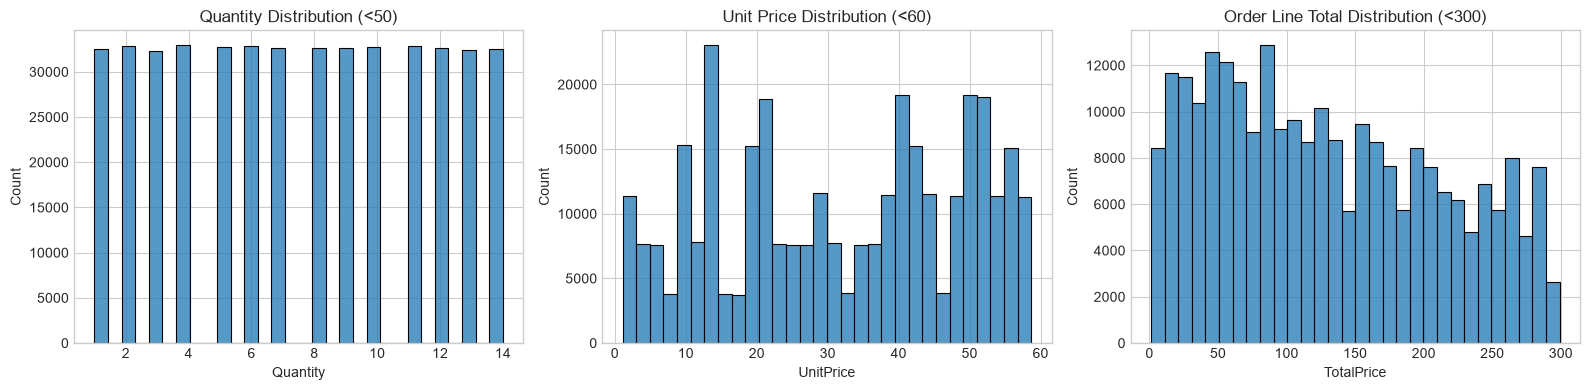

In [10]:
valid = sales[(sales["Quantity"] > 0) & (sales["UnitPrice"] > 0)].copy()
valid["TotalPrice"] = valid["Quantity"] * valid["UnitPrice"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(valid[valid["Quantity"] < 50]["Quantity"], bins=30, ax=axes[0])
axes[0].set_title("Quantity Distribution (<50)")

sns.histplot(valid[valid["UnitPrice"] < 60]["UnitPrice"], bins=30, ax=axes[1])
axes[1].set_title("Unit Price Distribution (<60)")

sns.histplot(valid[valid["TotalPrice"] < 300]["TotalPrice"], bins=30, ax=axes[2])
axes[2].set_title("Order Line Total Distribution (<300)")

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day1_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

### 6.4 Revenue Trend & Country Mix

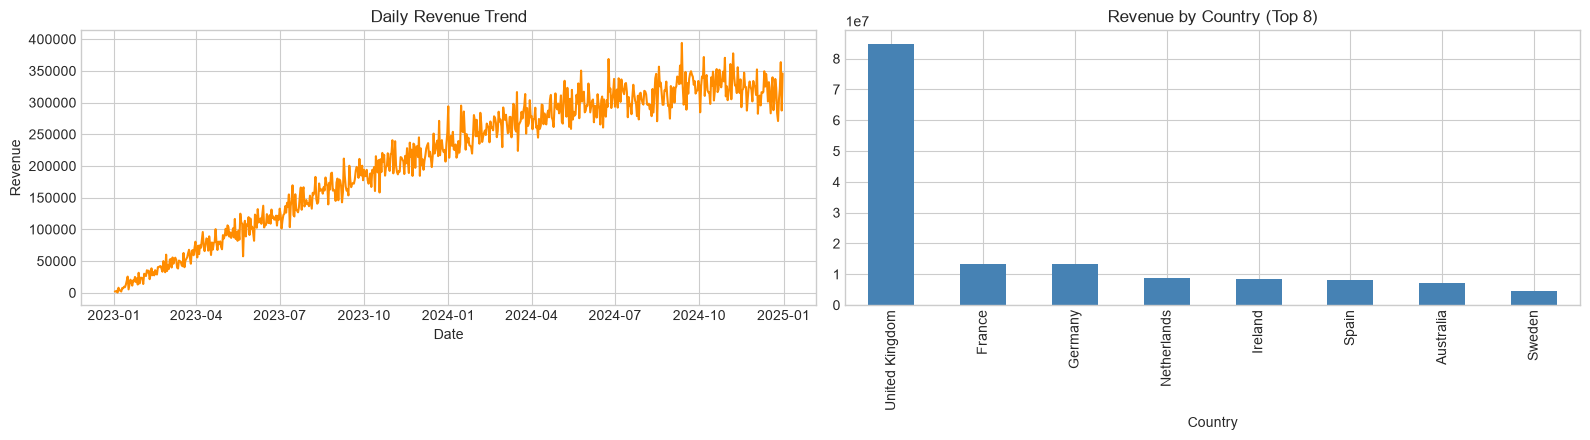

In [11]:
daily_revenue = valid.groupby(valid["InvoiceDate"].dt.date)["TotalPrice"].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
daily_revenue.plot(ax=axes[0], color="darkorange")
axes[0].set_title("Daily Revenue Trend")
axes[0].set_xlabel("Date"); axes[0].set_ylabel("Revenue")

top_countries = valid.groupby("Country")["TotalPrice"].sum().sort_values(ascending=False).head(8)
top_countries.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Revenue by Country (Top 8)")

plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day1_revenue_country.png", dpi=120, bbox_inches="tight")
plt.show()

### 6.5 Correlation Heatmap (customer-level view)

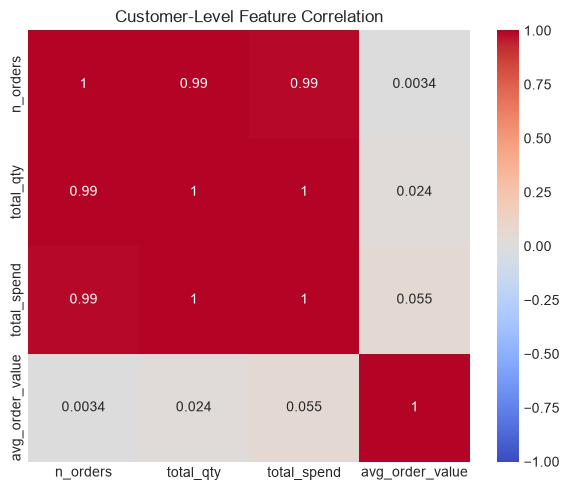

In [12]:
cust_view = (valid.dropna(subset=["CustomerID"])
             .groupby("CustomerID")
             .agg(n_orders=("InvoiceNo", "nunique"),
                  total_qty=("Quantity", "sum"),
                  total_spend=("TotalPrice", "sum"),
                  avg_order_value=("TotalPrice", "mean"))
             .reset_index())

plt.figure(figsize=(6, 5))
sns.heatmap(cust_view.drop(columns="CustomerID").corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Customer-Level Feature Correlation")
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day1_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

### 6.6 Lifecycle Sanity Check

Confirms the fix worked: churned customers' last purchase should cluster well before the dataset's end date, while loyal customers' last purchase should cluster near it.

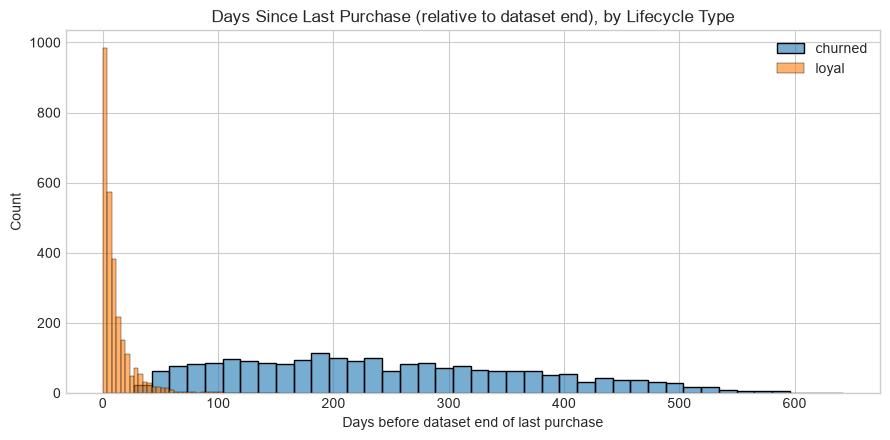

In [13]:
last_purchase = valid.dropna(subset=["CustomerID"]).groupby("CustomerID")["InvoiceDate"].max()
last_purchase_df = last_purchase.reset_index().merge(
    customers_df[["CustomerID", "LifecycleType"]], on="CustomerID")

plt.figure(figsize=(9, 4.5))
for lifecycle, group in last_purchase_df.groupby("LifecycleType"):
    days_before_end = (sales['InvoiceDate'].max() - group['InvoiceDate']).dt.days
    sns.histplot(days_before_end, label=lifecycle, alpha=0.6, bins=40)
plt.title("Days Since Last Purchase (relative to dataset end), by Lifecycle Type")
plt.xlabel("Days before dataset end of last purchase")
plt.legend()
plt.tight_layout()
plt.savefig(f"{REPORTS_DIR}/day1_lifecycle_check.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Day 1 Checkpoint Summary

**Outputs saved:**
- `data/raw/products_master.csv`, `customers_master.csv` (now with lifecycle fields), `sales_transactions.csv`, `inventory_snapshots.csv`
- `reports/day1_distributions.png`, `day1_revenue_country.png`, `day1_correlation.png`, `day1_lifecycle_check.png`

**v2 fix:** customers now have explicit signup/activity-end dates and individual purchase rates, with ~45% genuinely churning partway through the dataset. This gives Day 9's churn model real signal — churn is no longer near-zero and circular with the Recency feature.

**Data quality issues for Day 2 (unchanged from v1):** missing CustomerID, cancelled invoices, zero-qty/zero-price rows.

**Next module:** `02_cleaning_features` (re-run on this v2 data).